In [3]:
import numpy as np
import pandas as pd
data=pd.read_csv('NIFTY_6month.csv')
data.head()


,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,10-JUN-2024,23319.15,23411.90,23227.15,23259.20,304392368.0,29060.40
1,11-JUN-2024,23283.75,23389.45,23206.65,23264.85,305185666.0,29190.91
2,12-JUN-2024,23344.45,23441.95,23295.95,23322.95,295630910.0,31795.48
3,13-JUN-2024,23480.95,23481.05,23353.90,23398.90,268279841.0,30151.67
4,14-JUN-2024,23464.95,23490.40,23334.25,23465.60,223086741.0,25746.34


In [4]:
data.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
120,03-DEC-2024,24367.50,24481.35,24280.00,24457.15,339470947.0,34228.30
121,04-DEC-2024,24488.75,24573.20,24366.30,24467.45,348003156.0,34639.78
122,05-DEC-2024,24539.15,24857.75,24295.55,24708.40,361469920.0,40471.33
123,06-DEC-2024,24729.45,24751.05,24620.50,24677.80,226731303.0,23904.13
124,09-DEC-2024,24633.90,24705.00,24580.05,24619.00,248139308.0,25099.79


In [5]:
data['Date '] = pd.to_datetime(data['Date '])
data.set_index('Date ', inplace=True)

# Check for missing values and handle them if any
data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2024-06-10 to 2024-12-09
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             124 non-null    float64
 1   High             124 non-null    float64
 2   Low              124 non-null    float64
 3   Close            124 non-null    float64
 4   Shares Traded    124 non-null    float64
 5   Turnover (₹ Cr)  124 non-null    float64
dtypes: float64(6)
memory usage: 6.8 KB


C:\Users\Shahuraje\AppData\Local\Temp\ipykernel_10584\1848440799.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date '] = pd.to_datetime(data['Date '])


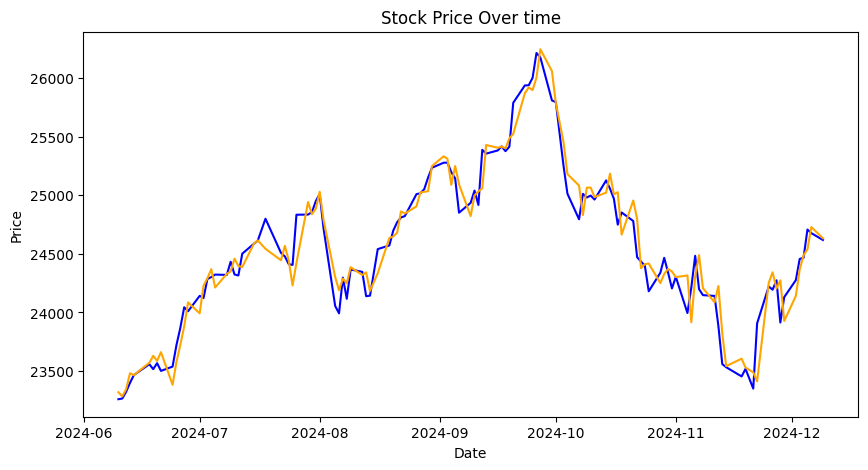

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(data['Close '],label='Close Price',color='blue')
plt.plot(data['Open '],label='Open Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

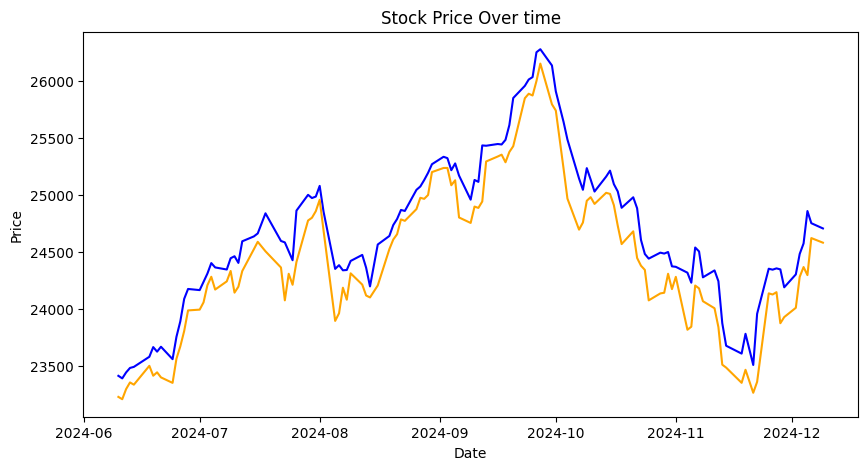

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data['High '],label='High Price',color='blue')
plt.plot(data['Low '],label='Low Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

#Check stationary

In [8]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(data['Close '])
print("ADF Statics : ",result[0])
print("p-value : ",result[1])
if(result[1]<=0.05):
    print("The data is stationary.")
else:
     print("The data is not stationary. Differencing might be required.")

ADF Statics :  -2.2172851759858263
p-value :  0.2000318533553696
The data is not stationary. Differencing might be required.


In [9]:
#differencing
data['Close_diff']=data['Close '].diff().dropna()
#Check data is stationary
result=adfuller(data['Close_diff'].dropna())
print("ADF Statics : ",result[0])
print("p-value : ",result[1])
if(result[1]<=0.05):
    print("The data is stationary.")
else:
     print("The data is not stationary. Differencing might be required.")


ADF Statics :  -10.228551640359122
p-value :  5.100160029457689e-18
The data is stationary.


#Autocorrelation and Partial Autocorrelation

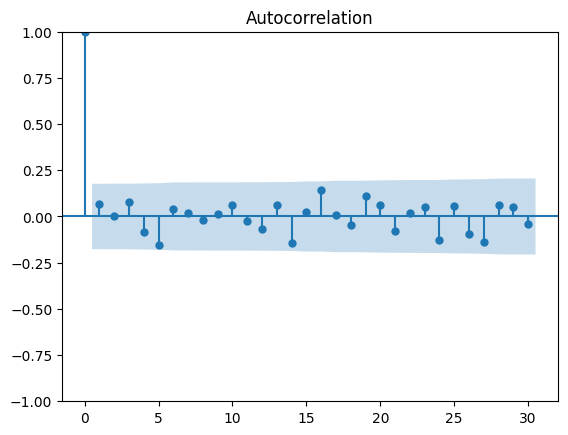

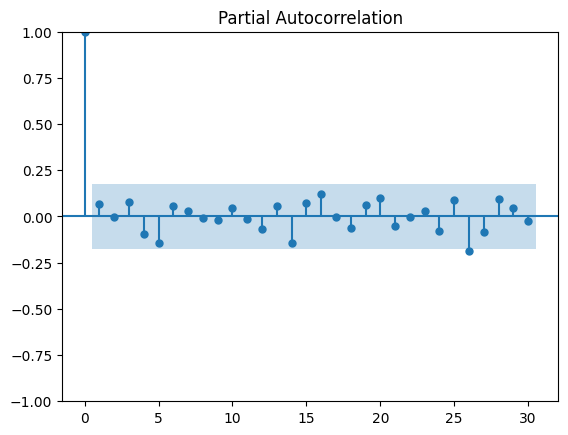

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data["Close_diff"].dropna(),lags=30)
plot_pacf(data["Close_diff"].dropna(),lags=30)
plt.show()

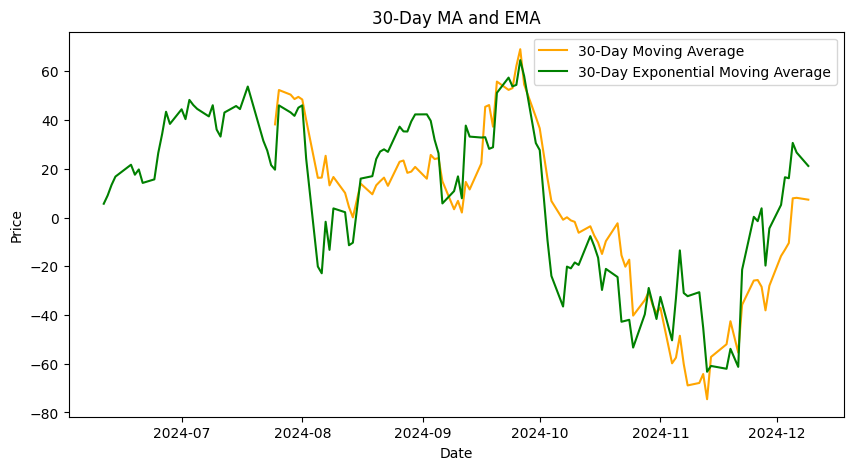

In [11]:
# Calculate 30-day Moving Average and Exponential Moving Average
data['30_day_MA'] = data['Close_diff'].rolling(window=30).mean()
data['30_day_EMA'] = data['Close_diff'].ewm(span=30, adjust=False).mean()

# Plotting the Moving Averages
plt.figure(figsize=(10, 5))
plt.plot(data['30_day_MA'], label='30-Day Moving Average', color='orange')
plt.plot(data['30_day_EMA'], label='30-Day Exponential Moving Average', color='green')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('30-Day MA and EMA')
plt.legend()
plt.show()



In [12]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(data['Close '],order=(26,2,0))
arima_result=model.fit()
arima_result.summary()

c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Close    No. Observations:                  124
Model:                ARIMA(26, 2, 0)   Log Likelihood                -808.346
Date:                Fri, 13 Dec 2024   AIC                           1670.693
Time:                        15:50:55   BIC                           1746.401
Sample:                             0   HQIC                          1701.443
                                - 124                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8065      0.077    -10.465      0.000      -0.958      -0.655
ar.L2         -0.7115      0.123     -5.765      0.000      -0.953      -0.470
ar.L3         -0.6349      0.159     -4.003      0.000      -0.946      -0.324
ar.L4         -0.6922      0.156     -4.430      0.000      -0.998      -0.386
ar.L5         -0.7759      0.187     -4.146      0.000      -1.143      -0.409
ar.L6         -0.6652      0.232     -2.864      0.004      -1.120      -0.210
ar.L7         -0.5877      0.243     -2.421      0.015      -1.064      -0.112
ar.L8         -0.5698      0.262     -2.174      0.030      -1.083      -0.056
ar.L9         -0.5888      0.262     -2.243      0.025      -1.103      -0.074
ar.L10        -0.4890      0.286     -1.711      0.087      -1.049       0.071
ar.L11        -0.3277      0.322     -1.017      0.309      -0.959       0.304
ar.L12        -0.3375      0.290     -1.165      0.244      -0.905       0.230
ar.L13        -0.3139      0.296     -1.061      0.289      -0.894       0.266
ar.L14        -0.3992      0.299     -1.333      0.182      -0.986       0.188
ar.L15        -0.2633      0.317     -0.832      0.406      -0.884       0.357
ar.L16        -0.0659      0.330     -0.200      0.842      -0.713       0.581
ar.L17        -0.0730      0.312     -0.234      0.815      -0.685       0.539
ar.L18        -0.0929      0.278     -0.334      0.738      -0.638       0.452
ar.L19        -0.0141      0.241     -0.058      0.953      -0.487       0.459
ar.L20         0.1497      0.235      0.636      0.525      -0.312       0.611
ar.L21         0.0959      0.217      0.441      0.659      -0.330       0.522
ar.L22         0.0623      0.198      0.314      0.753      -0.326       0.450
ar.L23         0.1502      0.199      0.753      0.451      -0.241       0.541
ar.L24         0.1297      0.163      0.798      0.425      -0.189       0.448
ar.L25         0.2444      0.133      1.837      0.066      -0.016       0.505
ar.L26         0.1109      0.087      1.278      0.201      -0.059       0.281
sigma2       2.76e+04   3311.128      8.335      0.000    2.11e+04    3.41e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 3.86
Prob(Q):                              0.81   Prob(JB):                         0.15
Heteroskedasticity (H):               0.96   Skew:                             0.02
Prob(H) (two-sided):                  0.91   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


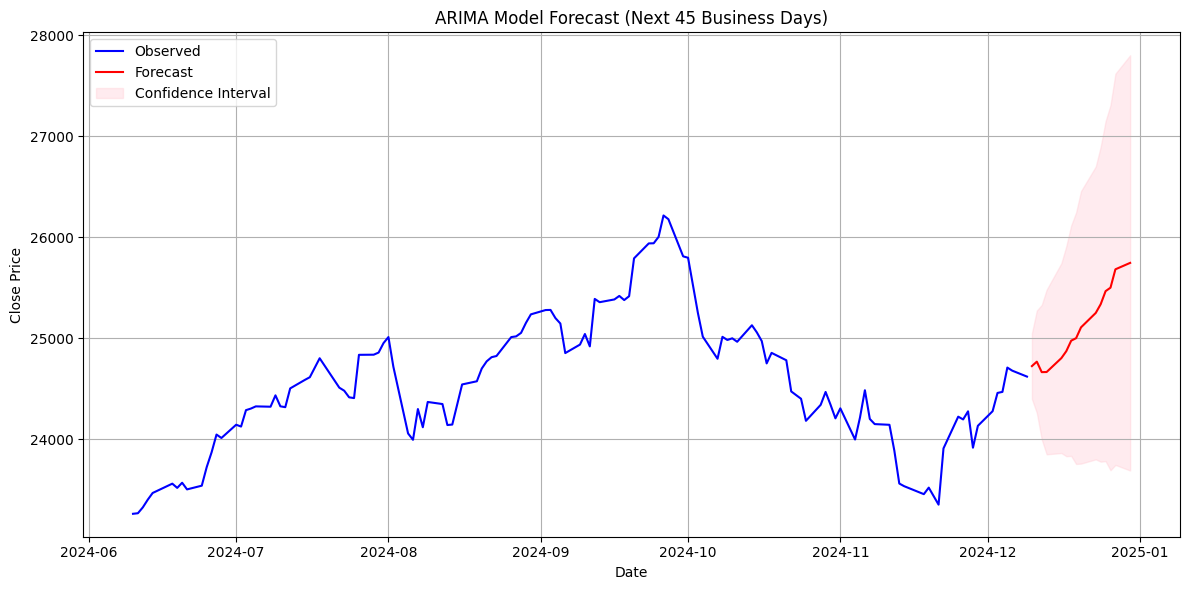

In [13]:
# Forecast the next 45 days
forecast_steps = 15
forecast = arima_result.get_forecast(steps=forecast_steps)

# Create a new index for the forecast
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

# Extract forecasted values and confidence intervals
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the observed data and forecast
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close '], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(
    forecast_index,
    forecast_ci.iloc[:, 0],  # Lower bound of the confidence interval
    forecast_ci.iloc[:, 1],  # Upper bound of the confidence interval
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

# Customize the plot
plt.title('ARIMA Model Forecast (Next 45 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
import numpy as np

# Calculate RMSE manually
train_predictions = arima_result.fittedvalues
rmse = np.sqrt(((train_predictions - data['Close ']) ** 2).mean())
print("RMSE:", rmse)



RMSE: 2343.6226141443067


In [15]:
# Save the forecast to a CSV file
forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecast': forecast_mean,
    'Lower_CI': forecast_ci.iloc[:, 0],
    'Upper_CI': forecast_ci.iloc[:, 1]
})
forecast_df.to_csv('forecasted_data.csv', index=False)
df=pd.read_csv('forecasted_data.csv')
df



,Date,Forecast,Lower_CI,Upper_CI
0,2024-12-10,24723.012168,24397.406663,25048.617672
1,2024-12-11,24767.078866,24260.102040,25274.055692
2,2024-12-12,24663.242542,23997.348167,25329.136917
3,2024-12-13,24664.464830,23848.832311,25480.097349
4,2024-12-16,24802.170054,23861.380927,25742.959181
5,2024-12-17,24870.805386,23830.244495,25911.366278
6,2024-12-18,24975.091344,23832.876395,26117.306294
7,2024-12-19,24999.837692,23752.969447,26246.705937
8,2024-12-20,25107.172314,23756.752158,26457.592471
9,2024-12-23,25250.019562,23798.878211,26701.160913
